In [ ]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Weight Quantization Implementation (DoReFa-Net Section 2.3)

class QuantizeWeights(torch.autograd.Function):
    """
    Quantize weights to k-bit using DoReFa-Net method (Equation 9)
    Implements straight-through estimator for gradients (Equation 6, 10)
    """

    @staticmethod
    def forward(ctx, weights, k_bits):
        """
        Forward: quantize weights to k-bit

        From DoReFa-Net Algorithm 1, Line 2: W_k^b ← f_ω^W(W_k)

        Args:
            weights: full precision weights (32-bit)
            k_bits: target bitwidth (1, 4, 8, 32)

        Returns:
            quantized weights in range [-1, 1]
        """
        if k_bits == 32:
            # Baseline: no quantization
            return weights

        elif k_bits == 1:
            # Binary weights (Equation 7): ro = sign(ri) × E(|ri|)
            scale = weights.abs().mean()
            quantized = weights.sign() * scale
            return quantized

        else:
            # k-bit quantization (Equation 9)
            # Step 1: tanh to limit range to [-1, 1]
            tanh_weights = torch.tanh(weights)

            # Step 2: Normalize to [0, 1]
            # Formula: tanh(ri) / (2 * max(|tanh(ri)|)) + 0.5
            max_val = tanh_weights.abs().max()
            normalized = tanh_weights / (2 * max_val + 1e-8) + 0.5

            # Step 3: Quantize using quantize_k (Equation 5)
            # ro = (1/(2^k - 1)) × round((2^k - 1) × ri)
            n_levels = 2 ** k_bits - 1
            quantized = torch.round(normalized * n_levels) / n_levels

            # Step 4: Map back to [-1, 1]
            quantized = 2 * quantized - 1

            return quantized

    @staticmethod
    def backward(ctx, grad_output):
        """
        Backward: straight-through estimator
        From Equation 6, 10: ∂c/∂ri = ∂c/∂ro
        """
        # Gradient passes through unchanged
        return grad_output, None  # None for k_bits (not learnable)


def quantize_weights(weights, k_bits):
    """Convenience wrapper for weight quantization"""
    return QuantizeWeights.apply(weights, k_bits)


print("Weight quantization functions defined")

Weight quantization functions defined


In [ ]:
# Test the quantization function

print("Testing weight quantization...\n")

# Create sample weights
test_weights = torch.randn(4, 4, requires_grad=True)
print("Original weights:")
print(test_weights)
print(f"Range: [{test_weights.min():.3f}, {test_weights.max():.3f}]")
print(f"Unique values: {len(torch.unique(test_weights))}\n")

# Test different bitwidths
results = []
for k in [1, 4, 8, 32]:
    quantized = quantize_weights(test_weights, k)
    unique_vals = len(torch.unique(quantized))

    results.append({
        'Bitwidth': k,
        'Unique Values': unique_vals,
        'Expected Max': 2**k if k < 32 else 'unlimited',
        'Min': f"{quantized.min():.3f}",
        'Max': f"{quantized.max():.3f}"
    })

    print(f"{k}-bit quantized:")
    print(f"  Unique values: {unique_vals} (expected ≤ {2**k if k < 32 else '∞'})")
    print(f"  Range: [{quantized.min():.3f}, {quantized.max():.3f}]")

    # Test gradient flow
    test_weights.grad = None  # Clear previous gradients
    loss = quantized.sum()
    loss.backward()
    print(f"  Gradient flows: {test_weights.grad is not None}")
    print()

# Display results table
df = pd.DataFrame(results)
display(df)

Testing weight quantization...

Original weights:
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]], requires_grad=True)
Range: [-2.106, 1.927]
Unique values: 16

1-bit quantized:
  Unique values: 2 (expected ≤ 2)
  Range: [-1.062, 1.062]
  Gradient flows: True

4-bit quantized:
  Unique values: 10 (expected ≤ 16)
  Range: [-1.000, 1.000]
  Gradient flows: True

8-bit quantized:
  Unique values: 16 (expected ≤ 256)
  Range: [-1.000, 0.984]
  Gradient flows: True

32-bit quantized:
  Unique values: 16 (expected ≤ ∞)
  Range: [-2.106, 1.927]
  Gradient flows: True



,Bitwidth,Unique Values,Expected Max,Min,Max
0,1,2,2,-1.062,1.062
1,4,10,16,-1.000,1.000
2,8,16,256,-1.000,0.984
3,32,16,unlimited,-2.106,1.927


In [ ]:
# Quantizable Conv2d Layer

class QuantizableConv2d(nn.Module):
    """
    Convolutional layer that maintains full-precision weights
    but uses quantized weights during forward pass

    Implements DoReFa-Net Algorithm 1, Lines 2-3
    """

    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, k_bits=32):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.k_bits = k_bits

        # Full precision weights (stored and updated)
        # This is the "W_k" in Algorithm 1
        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, kernel_size, kernel_size)
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

        # Initialize weights (Glorot/Kaiming initialization)
        nn.init.kaiming_normal_(self.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        """
        Forward pass using quantized weights

        Algorithm 1, Line 2-3:
          Line 2: W_k^b ← f_ω^W(W_k)
          Line 3: ã_k ← forward(a_{k-1}^b, W_k^b)
        """
        # Line 2: Quantize weights
        quantized_weight = quantize_weights(self.weight, self.k_bits)

        # Line 3: Convolution with quantized weights
        output = F.conv2d(x, quantized_weight, self.bias,
                         self.stride, self.padding)
        return output

    def extra_repr(self):
        """String representation for print(model)"""
        return f'{self.in_channels}, {self.out_channels}, kernel_size={self.kernel_size}, k_bits={self.k_bits}'


print("QuantizableConv2d layer defined")

QuantizableConv2d layer defined


In [ ]:
# CNN Model Architecture

class SimpleCNN(nn.Module):
    """
    Simple CNN for MNIST/CIFAR-10

    Architecture:
      Conv(3->32) -> ReLU -> Pool ->
      Conv(32->64) -> ReLU -> Pool ->
      Flatten -> FC(64*8*8->128) -> ReLU -> FC(128->10)

    From Section 2.7: First and last layers kept at full precision
    (but we'll quantize all layers for experimentation)
    """

    def __init__(self, num_classes=10, k_bits=32, input_size=32):
        super().__init__()
        self.k_bits = k_bits
        self.input_size = input_size

        # Convolutional layers (quantizable)
        self.conv1 = QuantizableConv2d(3, 32, kernel_size=3, padding=1, k_bits=k_bits)
        self.conv2 = QuantizableConv2d(32, 64, kernel_size=3, padding=1, k_bits=k_bits)
        self.pool = nn.MaxPool2d(2, 2)

        # Calculate FC input size
        # After two pooling layers: 32 -> 16 -> 8
        fc_input_size = 64 * (input_size // 4) * (input_size // 4)

        # Fully connected layers (full precision for now)
        self.fc1 = nn.Linear(fc_input_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Algorithm 1, Line 3-4: forward + activation
        x = self.pool(F.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 16x16 -> 8x8

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # No activation on final layer (for CrossEntropyLoss)

        return x

    def count_parameters(self):
        """Count total trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("SimpleCNN model defined")

SimpleCNN model defined


In [ ]:
# Test the CNN model

print("Testing SimpleCNN with different bitwidths...\n")

results = []
for k in [1, 4, 8, 32]:
    print(f"{'='*60}")
    print(f"Testing {k}-bit model")
    print(f"{'='*60}")

    model = SimpleCNN(num_classes=10, k_bits=k, input_size=32)

    # Test forward pass
    dummy_input = torch.randn(4, 3, 32, 32)  # Batch of 4 images
    output = model(dummy_input)

    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")

    # Count parameters
    n_params = model.count_parameters()
    print(f"Total parameters: {n_params:,}")

    # Check weight quantization in conv1
    conv1_weights = model.conv1.weight
    quantized = quantize_weights(conv1_weights, k)
    unique_vals = len(torch.unique(quantized))
    print(f"Conv1 unique weight values: {unique_vals}")

    # Test backward pass
    loss = output.sum()
    loss.backward()
    grad_exists = model.conv1.weight.grad is not None
    print(f"Gradients computed: {grad_exists}")

    results.append({
        'Bitwidth': k,
        'Parameters': n_params,
        'Conv1 Unique Weights': unique_vals,
        'Gradients OK': '✓' if grad_exists else '✗'
    })
    print()

# Summary table
df = pd.DataFrame(results)
display(df)

Testing SimpleCNN with different bitwidths...

Testing 1-bit model
Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 545,098
Conv1 unique weight values: 2
Gradients computed: True

Testing 4-bit model
Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 545,098
Conv1 unique weight values: 16
Gradients computed: True

Testing 8-bit model
Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 545,098
Conv1 unique weight values: 182
Gradients computed: True

Testing 32-bit model
Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Total parameters: 545,098
Conv1 unique weight values: 864
Gradients computed: True



,Bitwidth,Parameters,Conv1 Unique Weights,Gradients OK
0,1,545098,2,✓
1,4,545098,16,✓
2,8,545098,182,✓
3,32,545098,864,✓


In [ ]:
# Dataset loaders

def get_mnist_loaders(batch_size=128, data_dir='./data'):
    """
    Get MNIST data loaders

    Note: MNIST is grayscale, we convert to 3 channels and resize to 32x32
    to match CIFAR-10 input size
    """
    transform = transforms.Compose([
        transforms.Resize(32),  # 28x28 -> 32x32
        transforms.Grayscale(num_output_channels=3),  # 1 channel -> 3 channels
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )
    test_dataset = datasets.MNIST(
        root=data_dir, train=False, download=True, transform=transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    return train_loader, test_loader


def get_cifar10_loaders(batch_size=128, data_dir='./data'):
    """
    Get CIFAR-10 data loaders with data augmentation
    """
    # Training transform (with augmentation)
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Test transform (no augmentation)
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform_train
    )
    test_dataset = datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform_test
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    return train_loader, test_loader


print("Data loading functions defined")

Data loading functions defined


Loading datasets...



100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


✓ MNIST loaded
  Train batches: 938
  Test batches:  157


100%|██████████| 170M/170M [00:05<00:00, 32.3MB/s]



✓ CIFAR-10 loaded
  Train batches: 782
  Test batches:  157


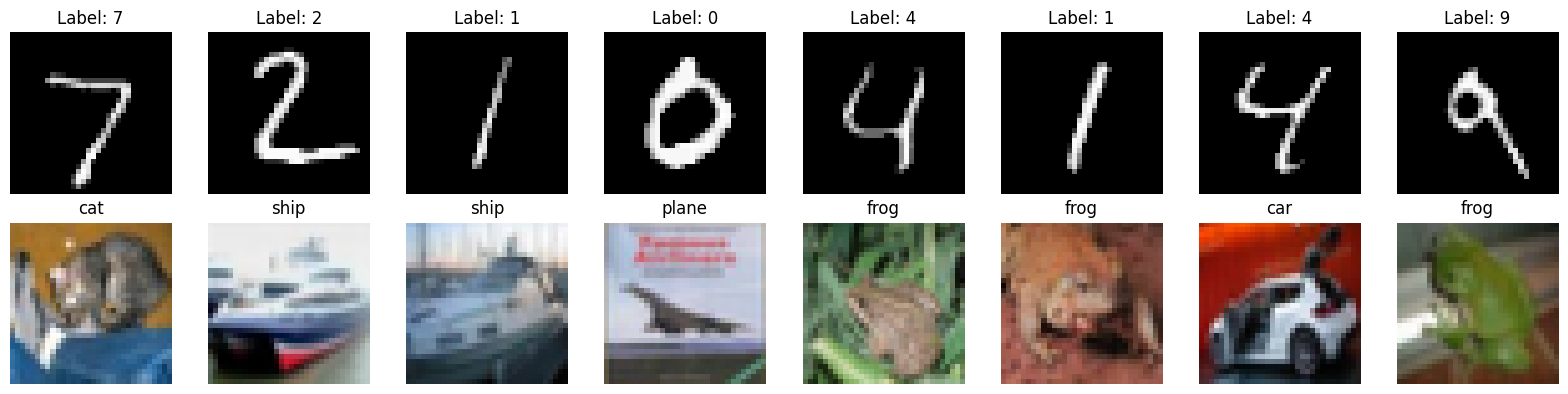

In [ ]:
# Load datasets and visualize samples

print("Loading datasets...\n")

# Load MNIST
mnist_train, mnist_test = get_mnist_loaders(batch_size=64)
print(f"✓ MNIST loaded")
print(f"  Train batches: {len(mnist_train)}")
print(f"  Test batches:  {len(mnist_test)}")

# Load CIFAR-10
cifar_train, cifar_test = get_cifar10_loaders(batch_size=64)
print(f"\n✓ CIFAR-10 loaded")
print(f"  Train batches: {len(cifar_train)}")
print(f"  Test batches:  {len(cifar_test)}")

# Visualize samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# MNIST samples
mnist_images, mnist_labels = next(iter(mnist_test))
for i in range(8):
    axes[0, i].imshow(mnist_images[i].permute(1, 2, 0), cmap='gray')
    axes[0, i].set_title(f"Label: {mnist_labels[i]}")
    axes[0, i].axis('off')

# CIFAR-10 samples
cifar_images, cifar_labels = next(iter(cifar_test))
cifar_classes = ['plane', 'car', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(8):
    # Denormalize CIFAR images for display
    img = cifar_images[i]
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)

    axes[1, i].imshow(img.permute(1, 2, 0))
    axes[1, i].set_title(f"{cifar_classes[cifar_labels[i]]}")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MNIST', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('CIFAR-10', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Training function (Algorithm 1, complete loop)

def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch

    Implements Algorithm 1:
      - Line 2-9: Forward pass with quantized weights
      - Line 10-16: Backward pass
      - Line 17-20: Update full-precision weights
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training', leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)

        # Algorithm 1, Line 2-9: Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Algorithm 1, Line 10-16: Backward pass
        loss.backward()

        # Algorithm 1, Line 17-20: Update full-precision weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.3f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc='Evaluating', leave=False):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = 100. * correct / total

    return test_loss, test_acc


print("Training functions defined")

Training functions defined


In [ ]:
# Test training on one model (quick sanity check)

print("Testing training loop with 32-bit baseline...\n")

# Create model
test_model = SimpleCNN(num_classes=10, k_bits=32).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(test_model.parameters(), lr=0.001)

# Use small subset of MNIST for quick test
mnist_train_small, mnist_test_small = get_mnist_loaders(batch_size=128)

# Train for 2 epochs
for epoch in range(2):
    print(f"\nEpoch {epoch+1}/2")
    train_loss, train_acc = train_epoch(test_model, mnist_train_small,
                                        criterion, optimizer, device)
    test_loss, test_acc = evaluate(test_model, mnist_test_small,
                                   criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")

print("\n Training loop works!")

Testing training loop with 32-bit baseline...


Epoch 1/2


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.2141 | Train Acc: 93.64%
Test Loss:  0.0657 | Test Acc:  97.87%

Epoch 2/2


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.0510 | Train Acc: 98.47%
Test Loss:  0.0337 | Test Acc:  98.86%

 Training loop works!


In [ ]:
# Run experiments across all bitwidths
# This implements the configuration space exploration from Section 3.1

def run_experiment(dataset_name, bitwidths=[1, 4, 8, 32], epochs=10):
    """
    Run full experiment: train models at different bitwidths

    Mimics DoReFa-Net Table 1 (Section 3.1)

    Args:
        dataset_name: 'mnist' or 'cifar10'
        bitwidths: list of k-bit values to test
        epochs: number of training epochs

    Returns:
        results_df: pandas DataFrame with all results
    """
    print(f"{'='*70}")
    print(f"Running experiment on {dataset_name.upper()}")
    print(f"Bitwidths: {bitwidths}")
    print(f"Epochs: {epochs}")
    print(f"{'='*70}\n")

    # Load appropriate dataset
    if dataset_name.lower() == 'mnist':
        train_loader, test_loader = get_mnist_loaders(batch_size=128)
        num_classes = 10
    elif dataset_name.lower() == 'cifar10':
        train_loader, test_loader = get_cifar10_loaders(batch_size=128)
        num_classes = 10
    else:
        raise ValueError("dataset_name must be 'mnist' or 'cifar10'")

    # Store results
    results = []

    # Train model for each bitwidth
    for k_bits in bitwidths:
        print(f"\n{'='*70}")
        print(f"Training {k_bits}-bit model on {dataset_name.upper()}")
        print(f"{'='*70}")

        # Create model
        model = SimpleCNN(num_classes=num_classes, k_bits=k_bits).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Track best accuracy
        best_test_acc = 0.0
        train_history = []
        test_history = []

        # Training loop
        start_time = time.time()
        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")

            train_loss, train_acc = train_epoch(model, train_loader,
                                               criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader,
                                          criterion, device)

            train_history.append(train_acc)
            test_history.append(test_acc)

            if test_acc > best_test_acc:
                best_test_acc = test_acc

            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}% " +
                  f"(Best: {best_test_acc:.2f}%)")

        training_time = time.time() - start_time

        # Calculate model size (in MB)
        param_size = sum(p.numel() * k_bits for p in model.parameters()) / 8 / 1024 / 1024
        baseline_size = sum(p.numel() * 32 for p in model.parameters()) / 8 / 1024 / 1024

        # Store results
        results.append({
            'Dataset': dataset_name.upper(),
            'Bitwidth (W)': k_bits,
            'Final Train Acc (%)': train_history[-1],
            'Final Test Acc (%)': test_history[-1],
            'Best Test Acc (%)': best_test_acc,
            'Model Size (MB)': param_size,
            'Compression Ratio': baseline_size / param_size,
            'Training Time (s)': training_time,
            'Train History': train_history,
            'Test History': test_history
        })

        print(f"\n{'='*70}")
        print(f"✓ {k_bits}-bit model complete")
        print(f"  Best Test Accuracy: {best_test_acc:.2f}%")
        print(f"  Model Size: {param_size:.2f} MB ({baseline_size/param_size:.1f}× compression)")
        print(f"  Training Time: {training_time:.1f}s")
        print(f"{'='*70}")

    # Create results DataFrame
    results_df = pd.DataFrame(results)

    return results_df


print("Experiment runner defined")

Experiment runner defined


In [ ]:
# MNIST experiment

mnist_results = run_experiment(
    dataset_name='mnist',
    bitwidths=[1, 4, 8, 32],
    epochs=5  # Start with 5 epochs for testing, increase to 10-20 for final results
)

# Display results table
display(mnist_results[['Bitwidth (W)', 'Best Test Acc (%)',
                       'Model Size (MB)', 'Compression Ratio', 'Training Time (s)']])

Running experiment on MNIST
Bitwidths: [1, 4, 8, 32]
Epochs: 5


Training 1-bit model on MNIST

Epoch 1/5


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.2535 | Train Acc: 92.37%
Test Loss:  0.0563 | Test Acc:  98.09% (Best: 98.09%)

Epoch 2/5


Training:   0%|          | 0/469 [00:00<?, ?it/s]

...

Train Loss: 0.0250 | Train Acc: 99.21%
Test Loss:  0.0381 | Test Acc:  98.71% (Best: 98.79%)

Epoch 5/5


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.0183 | Train Acc: 99.38%
Test Loss:  0.0325 | Test Acc:  98.96% (Best: 98.96%)

✓ 32-bit model complete
  Best Test Accuracy: 98.96%
  Model Size: 2.08 MB (1.0× compression)
  Training Time: 136.1s


,Bitwidth (W),Best Test Acc (%),Model Size (MB),Compression Ratio,Training Time (s)
0,1,99.06,0.064981,32.0,136.484780
1,4,98.81,0.259923,8.0,135.212501
2,8,99.06,0.519846,4.0,135.863055
3,32,98.96,2.079384,1.0,136.073552


In [ ]:
# CIFAR-10 experiment

cifar_results = run_experiment(
    dataset_name='cifar10',
    bitwidths=[1, 4, 8, 32],
    epochs=5  # Start with 5 epochs for testing
)

# Display results table
display(cifar_results[['Bitwidth (W)', 'Best Test Acc (%)',
                       'Model Size (MB)', 'Compression Ratio', 'Training Time (s)']])

Running experiment on CIFAR10
Bitwidths: [1, 4, 8, 32]
Epochs: 5


Training 1-bit model on CIFAR10

Epoch 1/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.6325 | Train Acc: 40.71%
Test Loss:  1.3613 | Test Acc:  51.17% (Best: 51.17%)

Epoch 2/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Train Loss: 0.9995 | Train Acc: 64.69%
Test Loss:  0.8892 | Test Acc:  69.48% (Best: 69.48%)

Epoch 5/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.9358 | Train Acc: 66.89%
Test Loss:  0.8558 | Test Acc:  70.45% (Best: 70.45%)

✓ 32-bit model complete
  Best Test Accuracy: 70.45%
  Model Size: 2.08 MB (1.0× compression)
  Training Time: 115.7s


,Bitwidth (W),Best Test Acc (%),Model Size (MB),Compression Ratio,Training Time (s)
0,1,62.71,0.064981,32.0,113.092125
1,4,63.71,0.259923,8.0,113.916510
2,8,66.81,0.519846,4.0,115.785571
3,32,70.45,2.079384,1.0,115.701169


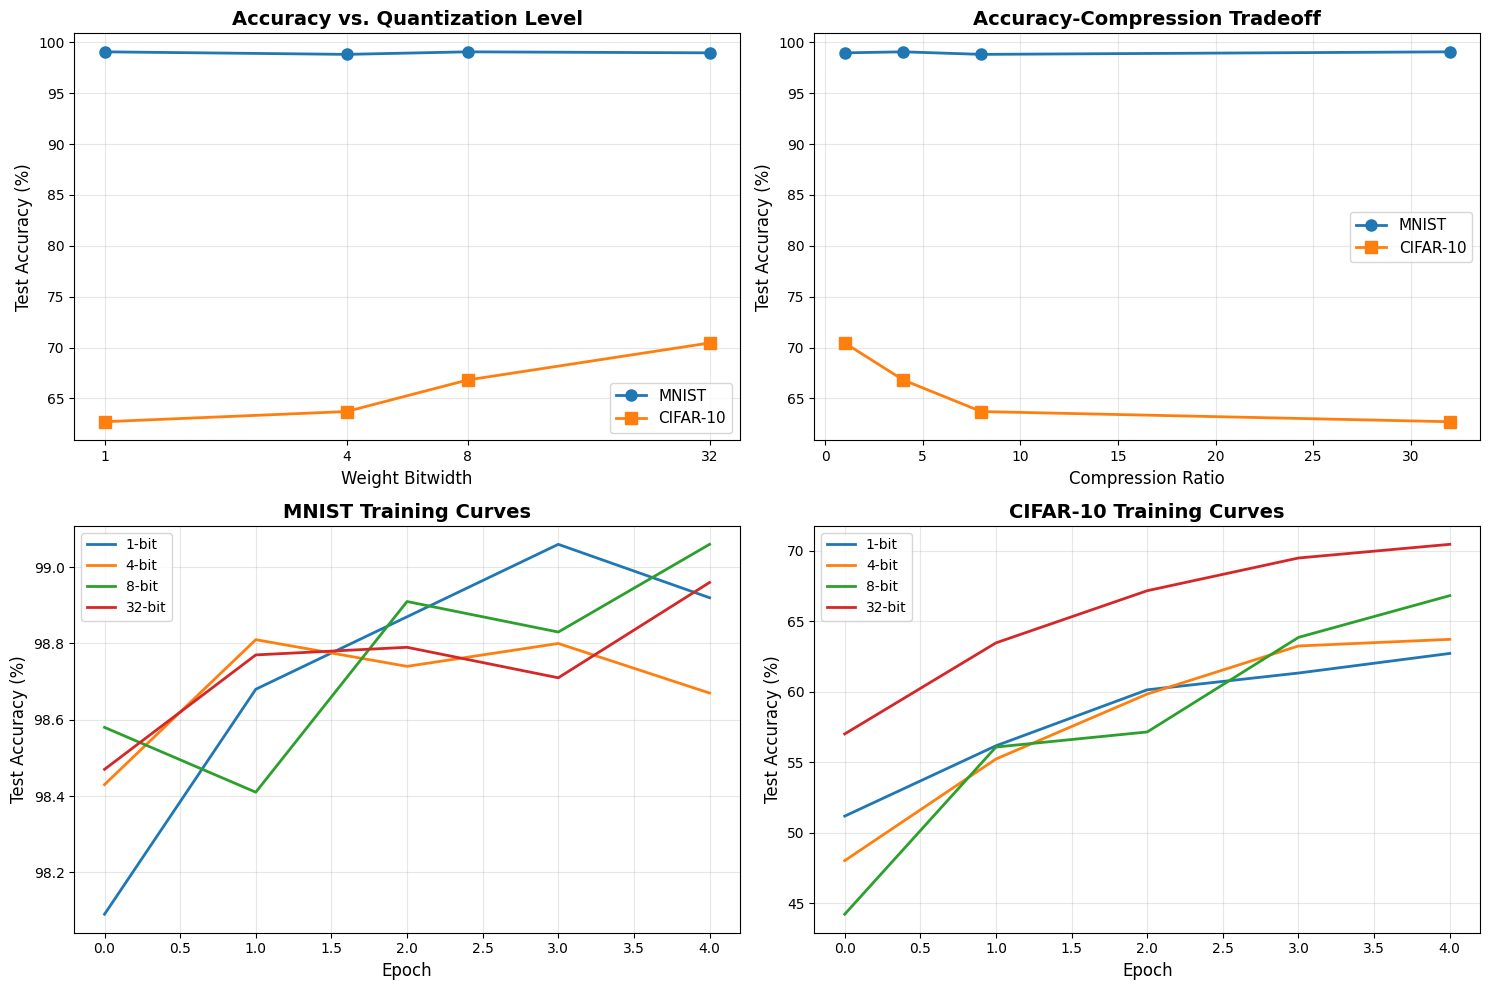

In [ ]:
# Plot results (mimics DoReFa-Net Figure 1)

def plot_results(mnist_results, cifar_results):
    """
    Create visualization of results
    Similar to DoReFa-Net Table 1 and Figure 1
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Accuracy vs Bitwidth
    ax = axes[0, 0]
    bitwidths = mnist_results['Bitwidth (W)'].values
    ax.plot(bitwidths, mnist_results['Best Test Acc (%)'],
            'o-', label='MNIST', linewidth=2, markersize=8)
    ax.plot(bitwidths, cifar_results['Best Test Acc (%)'],
            's-', label='CIFAR-10', linewidth=2, markersize=8)
    ax.set_xlabel('Weight Bitwidth', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Accuracy vs. Quantization Level', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log', base=2)
    ax.set_xticks(bitwidths)
    ax.set_xticklabels(bitwidths)

    # Plot 2: Compression vs Accuracy
    ax = axes[0, 1]
    ax.plot(mnist_results['Compression Ratio'], mnist_results['Best Test Acc (%)'],
            'o-', label='MNIST', linewidth=2, markersize=8)
    ax.plot(cifar_results['Compression Ratio'], cifar_results['Best Test Acc (%)'],
            's-', label='CIFAR-10', linewidth=2, markersize=8)
    ax.set_xlabel('Compression Ratio', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Accuracy-Compression Tradeoff', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Plot 3: Training curves for MNIST
    ax = axes[1, 0]
    for idx, row in mnist_results.iterrows():
        k = row['Bitwidth (W)']
        ax.plot(row['Test History'], label=f'{k}-bit', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('MNIST Training Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Plot 4: Training curves for CIFAR-10
    ax = axes[1, 1]
    for idx, row in cifar_results.iterrows():
        k = row['Bitwidth (W)']
        ax.plot(row['Test History'], label=f'{k}-bit', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('CIFAR-10 Training Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('quantization_results.png', dpi=300, bbox_inches='tight')
    plt.show()

# Generate plots
plot_results(mnist_results, cifar_results)

In [ ]:
# Generate table for paper

def create_results_table(mnist_results, cifar_results):
    """
    Create formatted table for paper
    Mimics DoReFa-Net Table 1 structure
    """
    combined = pd.concat([mnist_results, cifar_results])

    # Format table
    table = combined[['Dataset', 'Bitwidth (W)', 'Best Test Acc (%)',
                      'Model Size (MB)', 'Compression Ratio']].copy()
    table = table.round(2)
    table = table.sort_values(['Dataset', 'Bitwidth (W)'], ascending=[True, False])

    print("\n" + "="*80)
    print("RESULTS TABLE")
    print("="*80)
    display(table)

    # Calculate accuracy degradation from 32-bit baseline
    print("\n" + "="*80)
    print("ACCURACY DEGRADATION FROM 32-BIT BASELINE")
    print("="*80)

    for dataset in ['MNIST', 'CIFAR10']:
        dataset_results = combined[combined['Dataset'] == dataset]
        baseline_acc = dataset_results[dataset_results['Bitwidth (W)'] == 32]['Best Test Acc (%)'].values[0]

        print(f"\n{dataset}:")
        for _, row in dataset_results.iterrows():
            k = row['Bitwidth (W)']
            acc = row['Best Test Acc (%)']
            degradation = baseline_acc - acc
            print(f"  {k:2d}-bit: {acc:5.2f}% (Δ = {degradation:+5.2f}%)")

    # Save to CSV
    table.to_csv('quantization_results.csv', index=False)
    print("\n✓ Results saved to 'quantization_results.csv'")

create_results_table(mnist_results, cifar_results)


RESULTS TABLE


,Dataset,Bitwidth (W),Best Test Acc (%),Model Size (MB),Compression Ratio
3,CIFAR10,32,70.45,2.08,1.0
2,CIFAR10,8,66.81,0.52,4.0
1,CIFAR10,4,63.71,0.26,8.0
0,CIFAR10,1,62.71,0.06,32.0
3,MNIST,32,98.96,2.08,1.0
2,MNIST,8,99.06,0.52,4.0
1,MNIST,4,98.81,0.26,8.0
0,MNIST,1,99.06,0.06,32.0



ACCURACY DEGRADATION FROM 32-BIT BASELINE

MNIST:
   1-bit: 99.06% (Δ = -0.10%)
   4-bit: 98.81% (Δ = +0.15%)
   8-bit: 99.06% (Δ = -0.10%)
  32-bit: 98.96% (Δ = +0.00%)

CIFAR10:
   1-bit: 62.71% (Δ = +7.74%)
   4-bit: 63.71% (Δ = +6.74%)
   8-bit: 66.81% (Δ = +3.64%)
  32-bit: 70.45% (Δ = +0.00%)

✓ Results saved to 'quantization_results.csv'


In [ ]:
# Analysis for Discussion section of paper

print("="*80)
print("KEY FINDINGS FOR DISCUSSION SECTION")
print("="*80)

# Finding 1: Threshold identification
print("\n1. QUANTIZATION THRESHOLD ANALYSIS")
print("-" * 40)

for dataset_name, results in [('MNIST', mnist_results), ('CIFAR-10', cifar_results)]:
    baseline = results[results['Bitwidth (W)'] == 32]['Best Test Acc (%)'].values[0]
    print(f"\n{dataset_name} (Baseline: {baseline:.2f}%):")

    for _, row in results.iterrows():
        k = row['Bitwidth (W)']
        acc = row['Best Test Acc (%)']
        drop = baseline - acc
        compression = row['Compression Ratio']

        # Categorize degradation
        if drop < 1.0:
            category = "Negligible"
        elif drop < 3.0:
            category = "Acceptable"
        elif drop < 5.0:
            category = "Moderate"
        else:
            category = "Significant"

        print(f"  {k:2d}-bit: {acc:5.2f}% | Δ={drop:+5.2f}% | {compression:4.1f}× compression | {category}")

# Finding 2: Dataset complexity effect
print("\n\n2. DATASET COMPLEXITY EFFECT")
print("-" * 40)

for k in [1, 4, 8]:
    mnist_acc = mnist_results[mnist_results['Bitwidth (W)'] == k]['Best Test Acc (%)'].values[0]
    cifar_acc = cifar_results[cifar_results['Bitwidth (W)'] == k]['Best Test Acc (%)'].values[0]

    mnist_baseline = mnist_results[mnist_results['Bitwidth (W)'] == 32]['Best Test Acc (%)'].values[0]
    cifar_baseline = cifar_results[cifar_results['Bitwidth (W)'] == 32]['Best Test Acc (%)'].values[0]

    mnist_drop = mnist_baseline - mnist_acc
    cifar_drop = cifar_baseline - cifar_acc

    print(f"\n{k}-bit:")
    print(f"  MNIST degradation:   {mnist_drop:.2f}%")
    print(f"  CIFAR-10 degradation: {cifar_drop:.2f}%")
    print(f"  → More complex dataset shows {'HIGHER' if cifar_drop > mnist_drop else 'LOWER'} degradation")

# Finding 3: Efficiency gains
print("\n\n3. EFFICIENCY GAINS")
print("-" * 40)

for k in [1, 4, 8]:
    compression = mnist_results[mnist_results['Bitwidth (W)'] == k]['Compression Ratio'].values[0]
    acc = mnist_results[mnist_results['Bitwidth (W)'] == k]['Best Test Acc (%)'].values[0]
    baseline_acc = mnist_results[mnist_results['Bitwidth (W)'] == 32]['Best Test Acc (%)'].values[0]

    print(f"\n{k}-bit quantization:")
    print(f"  Model size: {compression:.1f}× smaller")
    print(f"  Accuracy retention: {100 * acc / baseline_acc:.1f}%")
    print(f"  → {'Favorable' if acc/baseline_acc > 0.95 else 'Moderate'} accuracy-compression tradeoff")

KEY FINDINGS FOR DISCUSSION SECTION

1. QUANTIZATION THRESHOLD ANALYSIS
----------------------------------------

MNIST (Baseline: 98.96%):
   1-bit: 99.06% | Δ=-0.10% | 32.0× compression | Negligible
   4-bit: 98.81% | Δ=+0.15% |  8.0× compression | Negligible
   8-bit: 99.06% | Δ=-0.10% |  4.0× compression | Negligible
  32-bit: 98.96% | Δ=+0.00% |  1.0× compression | Negligible

CIFAR-10 (Baseline: 70.45%):
   1-bit: 62.71% | Δ=+7.74% | 32.0× compression | Significant
   4-bit: 63.71% | Δ=+6.74% |  8.0× compression | Significant
   8-bit: 66.81% | Δ=+3.64% |  4.0× compression | Moderate
  32-bit: 70.45% | Δ=+0.00% |  1.0× compression | Negligible


2. DATASET COMPLEXITY EFFECT
----------------------------------------

1-bit:
  MNIST degradation:   -0.10%
  CIFAR-10 degradation: 7.74%
  → More complex dataset shows HIGHER degradation

4-bit:
  MNIST degradation:   0.15%
  CIFAR-10 degradation: 6.74%
  → More complex dataset shows HIGHER degradation

8-bit:
  MNIST degradation:   -0.1